# 06 — Multi-seed robustness of FedProx under heterogeneity

## Completed study

Notebook 05 found a small seed-42 benefit from moderate FedProx. This notebook tests whether that result survives independently seeded client partitions, data splits, initializations, and minibatch schedules while keeping all algorithmic hyperparameters fixed.

**Primary question.** Does moderate FedProx (`mu = 0.1`) consistently improve final performance or fairness relative to FedAvg (`mu = 0`), or was the seed-42 result partition-specific?

**Answer.** Moderate FedProx changed the optimization geometry consistently, but its performance benefit did not replicate consistently. It reduced median relative update magnitude in 3/3 seeds and made mean leave-one-out alignment less negative in 3/3 seeds, yet improved final weighted test accuracy in only 1/3 seeds. Strong FedProx (`mu = 1.0`) over-constrained local learning and performed substantially worse.

> Experimental unit: one seeded federated world (partition, split, initialization, and batch schedule). Client-round observations are diagnostics, not independent replicates.

## How to use this notebook

- **Reproduce training:** run Sections 1–13 from a clean repository checkout.
- **Analyze saved results after a restart:** extract `multiseed_fedprox.zip` to `results/`, run the setup/configuration cells, skip the full training cell, and run the restart-safe loader in Section 14.
- **Review on GitHub:** the completed outputs below are frozen from the three-seed experiment.

The archive is expected at `results/multiseed_fedprox/` and contains the exact initial states and partitions that should be reused for SCAFFOLD in Notebook 07.

## 1. Imports and environment

Run from the repository root or from `notebooks/`; the setup locates the project root automatically.


In [1]:
from __future__ import annotations

import copy
import inspect
import json
import math
import random
import sys
import time
from dataclasses import asdict, dataclass, replace
from pathlib import Path
from typing import Any, Callable, Dict, Iterable, Mapping, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn
import dataclasses
from torch.utils.data import DataLoader, Dataset, Subset

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Python: {sys.version.split()[0]}")
print(f"PyTorch: {torch.__version__}")
print(f"Device: {DEVICE}")

Python: 3.11.9
PyTorch: 2.13.0+cpu
Device: cpu


In [2]:
def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "src").is_dir():
            return candidate
    raise FileNotFoundError(
        "Could not find the repository root. Open the notebook inside the cloned repository."
    )


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: D:\HKU\New folder\federated-learning-under-heterogeneity-final\federated-learning-under-heterogeneity


### Repository integration cell

This is the only import cell that may need a small path-name adjustment if the repository has renamed a module. Keep all such adjustments here.

In [3]:
# Adjust only these imports if your current src/ module names differ.
from src.data import partition_dirichlet, split_client_indices

try:
    from src.models import SimpleMLP
except ImportError:
    from src.model import SimpleMLP

# Reuse Notebook 05's matched FedAvg/FedProx experiment runner.
from src.experiment import run_experiment

print("partition_dirichlet", inspect.signature(partition_dirichlet))
print("split_client_indices", inspect.signature(split_client_indices))
print("SimpleMLP", inspect.signature(SimpleMLP))
print("run_experiment", inspect.signature(run_experiment))

partition_dirichlet (train_ds, num_clients: int, alpha: float, seed: int)
split_client_indices (client_indices, train_fraction=0.8, validation_fraction=0.1, seed=42)
SimpleMLP (num_inputs, num_classes)
run_experiment (config, mu_values, initial_model, train_ds, client_train_indices, validation_loaders, loss_fn, device, verbose: bool = False)


## 2. Frozen experiment configuration

Do not change the seed list or `mu` values after viewing results. If a field differs from Notebook 05, change it now and document why.

In [4]:
@dataclass(frozen=True)
class MultiSeedConfig:
    seeds: Tuple[int, ...] = (42, 43, 44)
    mu_values: Tuple[float, ...] = (0.0, 0.1, 1.0)

    num_clients: int = 5
    alpha: float = 0.1
    local_epochs: int = 5
    num_rounds: int = 20
    batch_size: int = 64
    learning_rate: float = 0.01

    validation_fraction: float = 0.1
    test_fraction: float = 0.1
    num_workers: int = 0

    results_dir: Path = PROJECT_ROOT / "results" / "multiseed_fedprox"


CONFIG = MultiSeedConfig()
CONFIG.results_dir.mkdir(parents=True, exist_ok=True)
CONFIG

MultiSeedConfig(seeds=(42, 43, 44), mu_values=(0.0, 0.1, 1.0), num_clients=5, alpha=0.1, local_epochs=5, num_rounds=20, batch_size=64, learning_rate=0.01, validation_fraction=0.1, test_fraction=0.1, num_workers=0, results_dir=WindowsPath('D:/HKU/New folder/federated-learning-under-heterogeneity-final/federated-learning-under-heterogeneity/results/multiseed_fedprox'))

In [5]:
def json_ready(value: Any) -> Any:
    if isinstance(value, Path):
        try:
            return value.relative_to(PROJECT_ROOT).as_posix()
        except ValueError:
            return value.as_posix()
    if isinstance(value, tuple):
        return list(value)
    return value


config_payload = {key: json_ready(value) for key, value in asdict(CONFIG).items()}
with (CONFIG.results_dir / "config.json").open("w", encoding="utf-8") as handle:
    json.dump(config_payload, handle, indent=2)

print(json.dumps(config_payload, indent=2))

{
  "seeds": [
    42,
    43,
    44
  ],
  "mu_values": [
    0.0,
    0.1,
    1.0
  ],
  "num_clients": 5,
  "alpha": 0.1,
  "local_epochs": 5,
  "num_rounds": 20,
  "batch_size": 64,
  "learning_rate": 0.01,
  "validation_fraction": 0.1,
  "test_fraction": 0.1,
  "num_workers": 0,
  "results_dir": "results/multiseed_fedprox"
}


## 3. Load the MNIST training collection

Final evaluation uses client-local held-out subsets split from the MNIST training collection. The official MNIST test split is not loaded in this notebook.

In [6]:
from torchvision import datasets, transforms

MNIST_TRANSFORM = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

DATASET_DIR = PROJECT_ROOT / "datasets"
train_dataset = datasets.MNIST(
    root=DATASET_DIR, train=True, download=True, transform=MNIST_TRANSFORM
)

print(f"MNIST training examples: {len(train_dataset):,}")


MNIST training examples: 60,000


## 4. Experiment data structures

Store indices and initial weights—not active DataLoaders. Iterating a DataLoader mutates its generator state.

In [7]:
@dataclass
class SeedArtifacts:
    seed: int
    partition_indices: Dict[int, list[int]]
    train_indices: Dict[int, list[int]]
    validation_indices: Dict[int, list[int]]
    test_indices: Dict[int, list[int]]
    initial_state_dict: Dict[str, torch.Tensor]
    client_label_counts: Dict[int, Dict[int, int]]

@dataclass
class ConditionResult:
    seed: int
    mu: float
    final_model: nn.Module

    performance_history: pd.DataFrame
    client_performance_history: pd.DataFrame
    client_diagnostics: pd.DataFrame
    pairwise_diagnostics: pd.DataFrame
    round_diagnostics: pd.DataFrame

    runtime_seconds: float

## 5. Reusable utilities


In [8]:
def set_all_seeds(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def clone_state_dict(model: nn.Module) -> Dict[str, torch.Tensor]:
    return {
        name: tensor.detach().cpu().clone()
        for name, tensor in model.state_dict().items()
    }


def state_dict_vector(state_dict: Mapping[str, torch.Tensor]) -> torch.Tensor:
    return torch.cat([tensor.detach().cpu().reshape(-1) for tensor in state_dict.values()])


def labels_from_dataset(dataset: Dataset) -> np.ndarray:
    if hasattr(dataset, "targets"):
        targets = dataset.targets
        if isinstance(targets, torch.Tensor):
            return targets.detach().cpu().numpy()
        return np.asarray(targets)
    return np.asarray([int(dataset[index][1]) for index in range(len(dataset))])


def count_client_labels(
    dataset: Dataset, partition_indices: Mapping[int, Sequence[int]]
) -> Dict[int, Dict[int, int]]:
    labels = labels_from_dataset(dataset)
    result: Dict[int, Dict[int, int]] = {}
    for client_id, indices in partition_indices.items():
        values, counts = np.unique(labels[np.asarray(indices)], return_counts=True)
        result[int(client_id)] = {int(v): int(c) for v, c in zip(values, counts)}
    return result

## 6. Prepare one seed's immutable artifacts

For each seed, construct exactly one Dirichlet partition, one train/validation/test split, and one initial model state. The function deliberately has no `mu` argument: every condition within a seed must share these artifacts.

In [9]:

def prepare_seed_artifacts(
    seed: int,
    dataset: Dataset,
    config: MultiSeedConfig,
) -> SeedArtifacts:
    set_all_seeds(seed)

    partition_indices = partition_dirichlet(
        train_ds=dataset,
        num_clients=config.num_clients,
        alpha=config.alpha,
        seed=seed,
    )

    train_indices, validation_indices, test_indices = split_client_indices(
        client_indices=partition_indices,
        train_fraction=1.0 - config.validation_fraction - config.test_fraction,
        validation_fraction=config.validation_fraction,
        seed=seed,
    )

    set_all_seeds(seed)
    initial_model = SimpleMLP(784, 10)

    return SeedArtifacts(
        seed=seed,
        partition_indices={int(k): list(map(int, v)) for k, v in partition_indices.items()},
        train_indices=train_indices,
        validation_indices=validation_indices,
        test_indices=test_indices,
        initial_state_dict=clone_state_dict(initial_model),
        client_label_counts=count_client_labels(dataset, partition_indices),
    )


## 7. Fresh condition loaders

Every condition gets newly constructed training loaders with the same per-client generator seeds. Validation and test loaders are deterministic and unshuffled.

In [10]:
def loaders_from_indices(
    dataset: Dataset,
    indices_by_client: Mapping[int, Sequence[int]],
    *,
    batch_size: int,
    shuffle: bool,
    seed: int,
    num_workers: int = 0,
) -> Dict[int, DataLoader]:
    loaders: Dict[int, DataLoader] = {}
    for client_id in sorted(indices_by_client):
        generator = torch.Generator()
        generator.manual_seed(seed + int(client_id))
        loaders[int(client_id)] = DataLoader(
            Subset(dataset, list(indices_by_client[client_id])),
            batch_size=batch_size,
            shuffle=shuffle,
            generator=generator if shuffle else None,
            num_workers=num_workers,
        )
    return loaders


def build_condition_loaders(
    artifacts: SeedArtifacts,
    dataset: Dataset,
    config: MultiSeedConfig,
) -> tuple[Dict[int, DataLoader], Dict[int, DataLoader], Dict[int, DataLoader]]:
    common = dict(
        dataset=dataset,
        batch_size=config.batch_size,
        seed=artifacts.seed,
        num_workers=config.num_workers,
    )
    train_loaders = loaders_from_indices(
        indices_by_client=artifacts.train_indices, shuffle=True, **common
    )
    validation_loaders = loaders_from_indices(
        indices_by_client=artifacts.validation_indices, shuffle=False, **common
    )
    test_loaders = loaders_from_indices(
        indices_by_client=artifacts.test_indices, shuffle=False, **common
    )
    return train_loaders, validation_loaders, test_loaders

## 8. Reproducibility checks

These checks use temporary probe loaders, never the loaders used for training.

In [11]:
def assert_index_dict_equal(left: Mapping[int, list[int]], right: Mapping[int, list[int]]) -> None:
    assert set(left) == set(right)
    for client_id in left:
        assert left[client_id] == right[client_id]


def assert_split_integrity(artifacts: SeedArtifacts) -> None:
    for client_id in artifacts.partition_indices:
        full = set(artifacts.partition_indices[client_id])
        train = set(artifacts.train_indices[client_id])
        validation = set(artifacts.validation_indices[client_id])
        test = set(artifacts.test_indices[client_id])

        assert train.isdisjoint(validation)
        assert train.isdisjoint(test)
        assert validation.isdisjoint(test)
        assert train | validation | test == full


def batch_fingerprints(loaders: Mapping[int, DataLoader], num_batches: int = 3) -> Dict[int, list]:
    fingerprints: Dict[int, list] = {}
    for client_id, loader in loaders.items():
        items = []
        for batch_index, (inputs, targets) in enumerate(loader):
            if batch_index >= num_batches:
                break
            items.append((inputs.detach().cpu().clone(), targets.detach().cpu().clone()))
        fingerprints[int(client_id)] = items
    return fingerprints


def fingerprints_equal(left: Mapping[int, list], right: Mapping[int, list]) -> bool:
    if set(left) != set(right):
        return False
    for client_id in left:
        if len(left[client_id]) != len(right[client_id]):
            return False
        for (x_left, y_left), (x_right, y_right) in zip(left[client_id], right[client_id]):
            if not torch.equal(x_left, x_right) or not torch.equal(y_left, y_right):
                return False
    return True


def run_reproducibility_checks(dataset: Dataset, config: MultiSeedConfig) -> None:
    seed_a, seed_b = config.seeds[:2]
    a1 = prepare_seed_artifacts(seed_a, dataset, config)
    a2 = prepare_seed_artifacts(seed_a, dataset, config)
    b = prepare_seed_artifacts(seed_b, dataset, config)

    for field in ("partition_indices", "train_indices", "validation_indices", "test_indices"):
        assert_index_dict_equal(getattr(a1, field), getattr(a2, field))

    assert any(
        a1.partition_indices[cid] != b.partition_indices.get(cid, [])
        for cid in a1.partition_indices
    )

    assert_split_integrity(a1)
    assert_split_integrity(b)

    assert torch.equal(
        state_dict_vector(a1.initial_state_dict),
        state_dict_vector(a2.initial_state_dict),
    )
    assert not torch.equal(
        state_dict_vector(a1.initial_state_dict),
        state_dict_vector(b.initial_state_dict),
    )

    a_train_1, _, _ = build_condition_loaders(a1, dataset, config)
    a_train_2, _, _ = build_condition_loaders(a2, dataset, config)
    b_train, _, _ = build_condition_loaders(b, dataset, config)

    a_fp_1 = batch_fingerprints(a_train_1)
    a_fp_2 = batch_fingerprints(a_train_2)
    b_fp = batch_fingerprints(b_train)

    assert fingerprints_equal(a_fp_1, a_fp_2)
    assert not fingerprints_equal(a_fp_1, b_fp)

    print("All reproducibility checks passed.")


run_reproducibility_checks(train_dataset, CONFIG)

All reproducibility checks passed.


## 9. Partition audit

In [12]:
def partition_audit_frame(artifacts: SeedArtifacts) -> pd.DataFrame:
    rows = []
    for client_id, counts in artifacts.client_label_counts.items():
        total = sum(counts.values())
        dominant_label = max(counts, key=counts.get)
        row = {
            "seed": artifacts.seed,
            "client_id": client_id,
            "samples": total,
            "dominant_label": dominant_label,
            "dominant_label_fraction": counts[dominant_label] / total,
        }
        row.update({f"label_{label}": counts.get(label, 0) for label in range(10)})
        rows.append(row)
    return pd.DataFrame(rows).sort_values(["seed", "client_id"]).reset_index(drop=True)


def plot_partition_heatmap(audit_df: pd.DataFrame, seed: int) -> None:
    label_columns = [f"label_{label}" for label in range(10)]
    matrix = audit_df.set_index("client_id")[label_columns].to_numpy()
    proportions = matrix / matrix.sum(axis=1, keepdims=True)

    fig, ax = plt.subplots(figsize=(9, 3.5))
    image = ax.imshow(proportions, aspect="auto", cmap="Blues", vmin=0, vmax=1)
    ax.set_title(f"Client label proportions — seed {seed}")
    ax.set_xlabel("MNIST label")
    ax.set_ylabel("Client")
    ax.set_xticks(range(10), range(10))
    ax.set_yticks(range(len(audit_df)), audit_df["client_id"].tolist())
    fig.colorbar(image, ax=ax, label="Within-client proportion")
    plt.tight_layout()
    plt.show()

,seed,client_id,samples,dominant_label,dominant_label_fraction,label_0,label_1,label_2,label_3,label_4,label_5,label_6,label_7,label_8,label_9
0,42,0,8505,3,0.649735,7,0,0,5526,16,0,15,756,2182,3
1,42,1,8904,8,0.411950,0,91,627,11,2027,0,2306,0,3668,174
2,42,2,13325,2,0.399925,79,0,5329,44,1625,0,3450,1,0,2797
3,42,3,21164,1,0.314213,1721,6650,0,0,1950,5417,69,5357,0,0
4,42,4,8102,0,0.508023,4116,1,2,550,224,4,78,151,1,2975
5,43,0,8559,9,0.429606,318,0,0,5,5,1006,0,0,3548,3677
6,43,1,8408,0,0.352046,2960,7,559,0,0,2803,193,64,1822,0
7,43,2,9780,3,0.588037,553,86,33,5751,3333,5,0,0,19,0
8,43,3,22228,7,0.278927,2091,6021,881,366,0,1606,4935,6200,0,128
9,43,4,11025,2,0.406803,1,628,4485,9,2504,1,790,1,462,2144


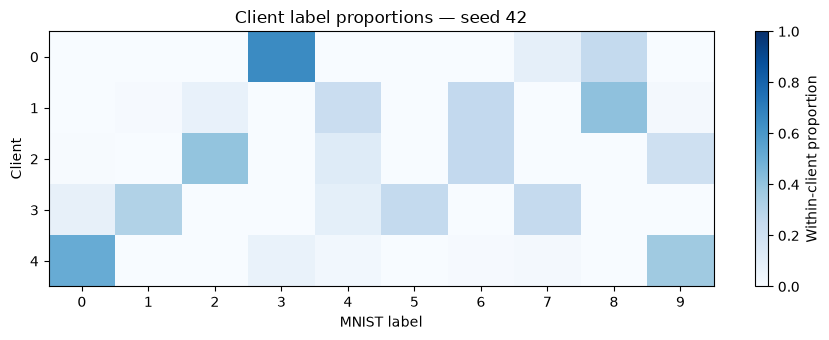

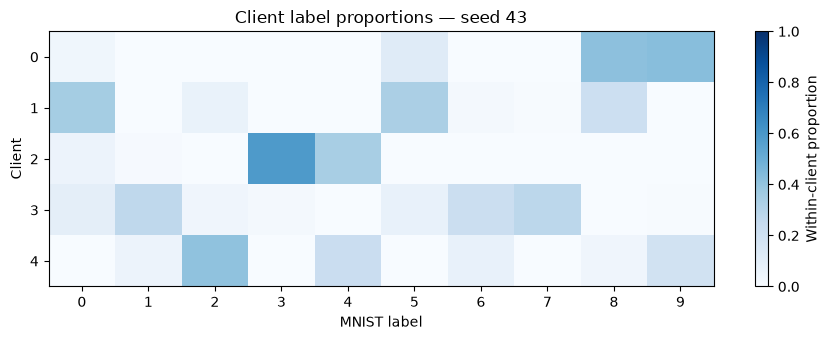

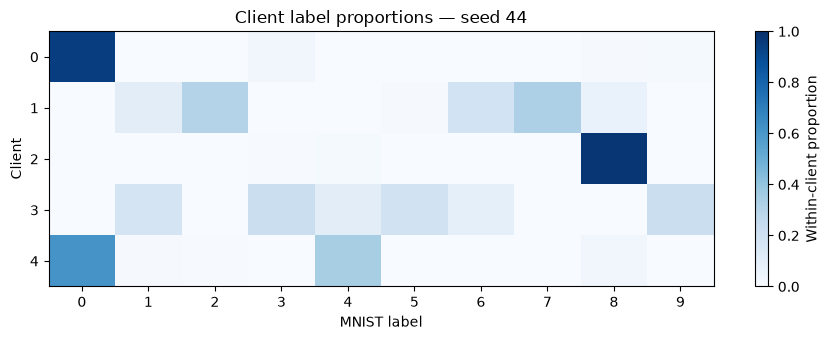

In [13]:
seed_artifacts = {
    seed: prepare_seed_artifacts(seed, train_dataset, CONFIG)
    for seed in CONFIG.seeds
}
partition_audit = pd.concat(
    [partition_audit_frame(artifacts) for artifacts in seed_artifacts.values()],
    ignore_index=True,
)
display(partition_audit)

for seed in CONFIG.seeds:
    plot_partition_heatmap(partition_audit.query("seed == @seed"), seed)

## 10. Evaluation and saving utilities


In [14]:
@torch.no_grad()
def accuracy_on_loader(model: nn.Module, loader: DataLoader, device: torch.device) -> tuple[int, int]:
    model.eval()
    correct = 0
    total = 0
    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)
        predictions = model(inputs).argmax(dim=1)
        correct += int((predictions == targets).sum().item())
        total += int(targets.numel())
    return correct, total


def evaluate_clients(
    model: nn.Module, loaders: Mapping[int, DataLoader], device: torch.device
) -> pd.DataFrame:
    model = model.to(device)
    rows = []
    for client_id, loader in sorted(loaders.items()):
        correct, total = accuracy_on_loader(model, loader, device)
        rows.append({
            "client_id": int(client_id),
            "correct": correct,
            "total": total,
            "accuracy": correct / total,
        })
    return pd.DataFrame(rows)


def save_seed_artifacts(artifacts: SeedArtifacts, root: Path) -> Path:
    seed_dir = root / f"seed_{artifacts.seed:04d}"
    seed_dir.mkdir(parents=True, exist_ok=True)

    index_fields = ("partition_indices", "train_indices", "validation_indices", "test_indices")
    for field in index_fields:
        with (seed_dir / f"{field}.json").open("w", encoding="utf-8") as handle:
            json.dump(getattr(artifacts, field), handle, indent=2)

    with (seed_dir / "client_label_counts.json").open("w", encoding="utf-8") as handle:
        json.dump(artifacts.client_label_counts, handle, indent=2)

    torch.save(artifacts.initial_state_dict, seed_dir / "initial_model.pt")
    return seed_dir


for artifacts in seed_artifacts.values():
    save_seed_artifacts(artifacts, CONFIG.results_dir)

partition_audit.to_csv(CONFIG.results_dir / "partition_audit.csv", index=False)

## 11. Adapt one condition to the existing Notebook 05 runner

`run_experiment` already implements the matched FedAvg/FedProx trajectories. This adapter runs exactly one `(seed, mu)` condition, reconstructs its final model, and exposes every returned diagnostic table under explicit names.

In [15]:
from dataclasses import asdict
from types import SimpleNamespace

def make_single_run_config(
    config: MultiSeedConfig,
    seed: int,
) -> SimpleNamespace:
    config_values = asdict(config)
    config_values["seed"] = seed
    return SimpleNamespace(**config_values)

In [16]:

def run_one_condition(
    *,
    seed: int,
    mu: float,
    initial_model: nn.Module,
    train_ds: Dataset,
    client_train_indices: Mapping[int, Sequence[int]],
    validation_loaders: Mapping[int, DataLoader],
    config: MultiSeedConfig,
    device: torch.device,
) -> ConditionResult:
    single_config = make_single_run_config(config=config, seed=seed)
    loss_fn = nn.CrossEntropyLoss()

    start_time = time.perf_counter()
    run_result = run_experiment(
        config=single_config,
        mu_values=(mu,),
        initial_model=copy.deepcopy(initial_model),
        train_ds=train_ds,
        client_train_indices=client_train_indices,
        validation_loaders=validation_loaders,
        loss_fn=loss_fn,
        device=device,
        verbose=False,
    )
    runtime_seconds = time.perf_counter() - start_time

    assert set(run_result.performance_history["seed"]) == {seed}
    assert set(run_result.performance_history["mu"]) == {mu}
    assert set(run_result.client_performance_history["seed"]) == {seed}
    assert set(run_result.client_performance_history["mu"]) == {mu}
    assert float(mu) in run_result.final_model_states

    final_model = copy.deepcopy(initial_model)
    final_model.load_state_dict(run_result.final_model_states[float(mu)])
    final_model = final_model.to(device)

    return ConditionResult(
        seed=seed,
        mu=mu,
        final_model=final_model,
        performance_history=run_result.performance_history.copy(),
        client_performance_history=run_result.client_performance_history.copy(),
        client_diagnostics=run_result.client_update_diagnostics.copy(),
        pairwise_diagnostics=run_result.pairwise_update_diagnostics.copy(),
        round_diagnostics=run_result.round_diagnostics.copy(),
        runtime_seconds=runtime_seconds,
    )


## 12. Smoke test

Run this before the full experiment: one seed, two conditions, two rounds, and one local epoch.

In [17]:
SMOKE_CONFIG = replace(
    CONFIG,
    seeds=(42,),
    mu_values=(0.0, 0.1),
    num_rounds=2,
    local_epochs=1,
    results_dir=CONFIG.results_dir / "smoke_test",
)
SMOKE_CONFIG.results_dir.mkdir(parents=True, exist_ok=True)
SMOKE_CONFIG

MultiSeedConfig(seeds=(42,), mu_values=(0.0, 0.1), num_clients=5, alpha=0.1, local_epochs=1, num_rounds=2, batch_size=64, learning_rate=0.01, validation_fraction=0.1, test_fraction=0.1, num_workers=0, results_dir=WindowsPath('D:/HKU/New folder/federated-learning-under-heterogeneity-final/federated-learning-under-heterogeneity/results/multiseed_fedprox/smoke_test'))

In [18]:
def execute_condition(
    artifacts: SeedArtifacts, mu: float, dataset: Dataset, config: MultiSeedConfig
) -> tuple[ConditionResult, pd.DataFrame]:
    set_all_seeds(artifacts.seed)
    model = SimpleMLP(784,10)
    model.load_state_dict(copy.deepcopy(artifacts.initial_state_dict))

    expected_initial = state_dict_vector(artifacts.initial_state_dict)
    actual_initial = state_dict_vector(model.state_dict())
    assert torch.equal(expected_initial, actual_initial)

    _, validation_loaders, test_loaders = build_condition_loaders(
        artifacts, dataset, config
    )

    result = run_one_condition(
        seed=artifacts.seed,
        mu=mu,
        initial_model=model,
        train_ds=dataset,
        client_train_indices=artifacts.train_indices,
        validation_loaders=validation_loaders,
        config=config,
        device=DEVICE,
    )
    client_test = evaluate_clients(result.final_model, test_loaders, DEVICE)
    client_test.insert(0, "mu", mu)
    client_test.insert(0, "seed", artifacts.seed)
    return result, client_test


smoke_artifacts = prepare_seed_artifacts(42, train_dataset, SMOKE_CONFIG)
smoke_results = []
for mu in SMOKE_CONFIG.mu_values:
    condition_result, client_test = execute_condition(
        smoke_artifacts, mu, train_dataset, SMOKE_CONFIG
    )
    smoke_results.append((condition_result, client_test))

assert len(smoke_results) == 2
for result, client_test in smoke_results:
    assert np.isfinite(client_test["accuracy"]).all()
    assert client_test["total"].gt(0).all()
    assert len(result.performance_history) == SMOKE_CONFIG.num_rounds + 1
    assert len(result.client_performance_history) == (SMOKE_CONFIG.num_rounds + 1) * SMOKE_CONFIG.num_clients
    assert np.isfinite(result.performance_history.select_dtypes(include="number")).all().all()

print("Smoke test passed.")

Smoke test passed.


## 13. Full multi-seed run

Run only after all reproducibility checks and the smoke test pass. Every completed condition is saved immediately so a disconnected session does not erase earlier work.

In [19]:
# Keep False when reviewing committed artifacts. Set True only to reproduce the expensive nine-condition run.
RUN_FULL_MULTI_SEED = False

if RUN_FULL_MULTI_SEED:
    all_performance = []
    all_client_performance = []
    all_client_diagnostics = []
    all_pairwise_diagnostics = []
    all_round_diagnostics = []
    all_client_test = []
    all_runtime = []

    for seed in CONFIG.seeds:
        artifacts = seed_artifacts[seed]
        seed_dir = save_seed_artifacts(artifacts, CONFIG.results_dir)

        for mu in CONFIG.mu_values:
            print(f"Running seed={seed}, mu={mu}")
            result, client_test = execute_condition(artifacts, mu, train_dataset, CONFIG)

            all_client_performance.append(result.client_performance_history)
            all_round_diagnostics.append(result.round_diagnostics)
            all_performance.append(result.performance_history)
            all_client_diagnostics.append(result.client_diagnostics)
            all_pairwise_diagnostics.append(result.pairwise_diagnostics)
            all_client_test.append(client_test)
            all_runtime.append({"seed": seed, "mu": mu, "runtime_seconds": result.runtime_seconds})

            mu_tag = str(mu).replace(".", "p")
            result.performance_history.to_csv(seed_dir / f"performance_mu_{mu_tag}.csv", index=False)
            result.client_diagnostics.to_csv(seed_dir / f"client_diagnostics_mu_{mu_tag}.csv", index=False)
            result.pairwise_diagnostics.to_csv(seed_dir / f"pairwise_diagnostics_mu_{mu_tag}.csv", index=False)
            result.client_performance_history.to_csv(seed_dir / f"client_performance_mu_{mu_tag}.csv", index=False)
            result.round_diagnostics.to_csv(seed_dir / f"round_diagnostics_mu_{mu_tag}.csv", index=False)
            client_test.to_csv(seed_dir / f"final_client_test_mu_{mu_tag}.csv", index=False)
            torch.save(result.final_model.state_dict(), seed_dir / f"final_model_mu_{mu_tag}.pt")

    performance_df = pd.concat(all_performance, ignore_index=True)
    client_diagnostics_df = pd.concat(all_client_diagnostics, ignore_index=True)
    pairwise_diagnostics_df = pd.concat(all_pairwise_diagnostics, ignore_index=True)
    client_test_df = pd.concat(all_client_test, ignore_index=True)
    client_performance_df = pd.concat(all_client_performance, ignore_index=True)
    round_diagnostics_df = pd.concat(all_round_diagnostics, ignore_index=True)
    runtime_df = pd.DataFrame(all_runtime)

    performance_df.to_csv(CONFIG.results_dir / "performance_history.csv", index=False)
    client_diagnostics_df.to_csv(CONFIG.results_dir / "client_update_diagnostics.csv", index=False)
    pairwise_diagnostics_df.to_csv(CONFIG.results_dir / "pairwise_update_diagnostics.csv", index=False)
    client_test_df.to_csv(CONFIG.results_dir / "final_client_test_metrics.csv", index=False)
    runtime_df.to_csv(CONFIG.results_dir / "runtime.csv", index=False)
    client_performance_df.to_csv(CONFIG.results_dir / "client_performance_history.csv",index=False,)
    round_diagnostics_df.to_csv(CONFIG.results_dir / "round_diagnostics.csv",index=False,)

    print("Full experiment finished and saved.")
else:
    print("Full nine-condition run skipped. Load committed results in the next section.")


Full nine-condition run skipped. Load committed results in the next section.


## 14. Reload saved results without rerunning training

This cell is the restart boundary. It reconstructs the analysis DataFrames from disk and allows Sections 15–18 to run in a fresh local or Kaggle kernel.

> **Artifact integrity note.** The original completed archive accidentally duplicated `performance_history` into `client_performance_history` in the adapter. Therefore, the archived per-client validation trajectory file must not be used. The adapter above is corrected for future runs. All conclusions below rely on the unaffected final client-test table, aggregate validation history, and geometry diagnostics.

In [20]:
RESULTS_DIR = PROJECT_ROOT / "results" / "multiseed_fedprox"

required_result_files = {
    "performance": "performance_history.csv",
    "client_diagnostics": "client_update_diagnostics.csv",
    "pairwise_diagnostics": "pairwise_update_diagnostics.csv",
    "round_diagnostics": "round_diagnostics.csv",
    "client_test": "final_client_test_metrics.csv",
    "runtime": "runtime.csv",
}

missing = [
    filename
    for filename in required_result_files.values()
    if not (RESULTS_DIR / filename).exists()
]
if missing:
    raise FileNotFoundError(
        "Extract multiseed_fedprox.zip into results/ before analysis. "
        f"Missing: {missing}"
    )

performance_df = pd.read_csv(RESULTS_DIR / required_result_files["performance"])
client_diagnostics_df = pd.read_csv(RESULTS_DIR / required_result_files["client_diagnostics"])
pairwise_diagnostics_df = pd.read_csv(RESULTS_DIR / required_result_files["pairwise_diagnostics"])
round_diagnostics_df = pd.read_csv(RESULTS_DIR / required_result_files["round_diagnostics"])
client_test_df = pd.read_csv(RESULTS_DIR / required_result_files["client_test"])
runtime_df = pd.read_csv(RESULTS_DIR / required_result_files["runtime"])

print(f"Loaded saved results from {RESULTS_DIR}")
print(f"Conditions: {len(runtime_df)} | performance rows: {len(performance_df)} | client-test rows: {len(client_test_df)}")

Loaded saved results from D:\HKU\New folder\federated-learning-under-heterogeneity-final\federated-learning-under-heterogeneity\results\multiseed_fedprox
Conditions: 9 | performance rows: 189 | client-test rows: 45


## 15. Seed-level and across-seed summaries

Each row below is one experimental unit: a complete `(seed, mu)` federated world. Across-seed standard deviations use `ddof=1`; client dispersion within a seed uses `ddof=0`. With only three seeds, the analysis is descriptive and paired—no significance tests are reported.

In [21]:
def first_existing_column(frame: pd.DataFrame, candidates: Sequence[str]) -> str:
    for column in candidates:
        if column in frame.columns:
            return column
    raise KeyError(f"None of these columns exist: {list(candidates)}")


def normalized_accuracy_auc(group: pd.DataFrame) -> float:
    ordered = group.sort_values("round")
    rounds = ordered["round"].to_numpy(dtype=float)
    accuracy = ordered["weighted_accuracy"].to_numpy(dtype=float)
    if len(rounds) < 2 or rounds[-1] == rounds[0]:
        return float(accuracy[-1])
    return float(np.trapezoid(accuracy, x=rounds) / (rounds[-1] - rounds[0]))


def build_seed_mu_summary(
    performance: pd.DataFrame,
    client_test: pd.DataFrame,
    client_diagnostics: pd.DataFrame,
    pairwise_diagnostics: pd.DataFrame,
    runtime: pd.DataFrame,
) -> pd.DataFrame:
    loo_column = first_existing_column(
        client_diagnostics,
        ("loo_alignment", "leave_one_out_alignment", "aggregate_alignment_loo"),
    )

    rows = []
    for (seed, mu), test_group in client_test.groupby(["seed", "mu"], sort=True):
        perf_group = performance.query("seed == @seed and mu == @mu")
        diag_group = client_diagnostics.query("seed == @seed and mu == @mu")
        pair_group = pairwise_diagnostics.query("seed == @seed and mu == @mu")
        runtime_value = runtime.query("seed == @seed and mu == @mu")["runtime_seconds"].iloc[0]

        rows.append({
            "seed": int(seed),
            "mu": float(mu),
            "final_weighted_test_accuracy": test_group["correct"].sum() / test_group["total"].sum(),
            "final_worst_client_accuracy": test_group["accuracy"].min(),
            "final_mean_client_accuracy": test_group["accuracy"].mean(),
            "client_accuracy_std": test_group["accuracy"].std(ddof=0),
            "normalized_validation_auc": normalized_accuracy_auc(perf_group),
            "median_relative_update_magnitude": diag_group["relative_update_magnitude"].median(),
            "mean_loo_alignment": diag_group[loo_column].mean(),
            "mean_pairwise_similarity": pair_group["cosine_similarity"].mean(),
            "runtime_seconds": float(runtime_value),
        })
    return pd.DataFrame(rows).sort_values(["seed", "mu"]).reset_index(drop=True)

In [22]:
seed_mu_summary = build_seed_mu_summary(
    performance_df, client_test_df, client_diagnostics_df, pairwise_diagnostics_df, runtime_df
)
seed_mu_summary.to_csv(CONFIG.results_dir / "seed_mu_summary.csv", index=False)
display(seed_mu_summary)

metric_columns = [column for column in seed_mu_summary.columns if column not in {"seed", "mu"}]
across_seed_summary = (
    seed_mu_summary.groupby("mu")[metric_columns]
    .agg(["mean", "std"])
)
across_seed_summary.to_csv(CONFIG.results_dir / "across_seed_summary.csv")
display(across_seed_summary)

,seed,mu,final_weighted_test_accuracy,final_worst_client_accuracy,final_mean_client_accuracy,client_accuracy_std,normalized_validation_auc,median_relative_update_magnitude,mean_loo_alignment,mean_pairwise_similarity,runtime_seconds
0,42,0.0,0.913043,0.857814,0.901101,0.034043,0.823166,0.067553,-0.196087,-0.025754,1088.990117
1,42,0.1,0.915376,0.867215,0.905988,0.028364,0.832102,0.057859,-0.171706,-0.021173,1069.493814
2,42,1.0,0.884391,0.804935,0.871592,0.040015,0.808394,0.037207,-0.185831,-0.017183,1082.557037
3,43,0.0,0.931213,0.879346,0.922699,0.031470,0.869360,0.064391,-0.143158,-0.025919,1079.205840
4,43,0.1,0.928215,0.875256,0.920700,0.031604,0.869089,0.055673,-0.108274,-0.015636,1074.269488
5,43,1.0,0.895736,0.825153,0.884740,0.039709,0.829215,0.036621,-0.134921,-0.019034,1077.330431
6,44,0.0,0.908077,0.750000,0.856441,0.067900,0.819051,0.057121,-0.186709,0.056337,1083.663036
7,44,0.1,0.900416,0.803571,0.863715,0.046986,0.811547,0.049870,-0.166657,0.046160,1076.617488
8,44,1.0,0.856453,0.571429,0.773928,0.114565,0.751055,0.035255,-0.200837,0.023209,1076.844750


final_weighted_test_accuracy           final_worst_client_accuracy  \
                            mean       std                        mean   
mu                                                                       
0.0                     0.917444  0.012180                    0.829053   
0.1                     0.914669  0.013913                    0.848681   
1.0                     0.878860  0.020217                    0.733839   

              final_mean_client_accuracy           client_accuracy_std  \
          std                       mean       std                mean   
mu                                                                       
0.0  0.069303                   0.893414  0.033791            0.044471   
0.1  0.039272                   0.896801  0.029582            0.035652   
1.0  0.141014                   0.843420  0.060540            0.064763   

              normalized_validation_auc            \
          std                      mean       std   
mu                                                  
0.0  0.020331                  0.837192  0.027934   
0.1  0.009949                  0.837580  0.029159   
1.0  0.043130                  0.796221  0.040477   

    median_relative_update_magnitude           mean_loo_alignment            \
                                mean       std               mean       std   
mu                                                                            
0.0                         0.063021  0.005349          -0.175318  0.028244   
0.1                         0.054467  0.004129          -0.148879  0.035256   
1.0                         0.036361  0.001002          -0.173863  0.034549   

    mean_pairwise_similarity           runtime_seconds            
                        mean       std            mean       std  
mu                                                                
0.0                 0.001555  0.047443     1083.952998  4.898579  
0.1                 0.003117  0.037379     1073.460263  3.630126  
1.0                -0.004336  0.023872     1078.910739  3.167110

In [23]:
def paired_difference_table(
    summary: pd.DataFrame, baseline_mu: float = 0.0, comparison_mu: float = 0.1
) -> pd.DataFrame:
    metrics = [
        "final_weighted_test_accuracy",
        "final_worst_client_accuracy",
        "final_mean_client_accuracy",
        "normalized_validation_auc",
    ]
    wide = summary.pivot(index="seed", columns="mu", values=metrics)
    difference = pd.DataFrame(index=wide.index)
    for metric in metrics:
        difference[f"{metric}_difference"] = (
            wide[(metric, comparison_mu)] - wide[(metric, baseline_mu)]
        )
    return difference.reset_index()


paired_differences = paired_difference_table(seed_mu_summary)
paired_differences.to_csv(CONFIG.results_dir / "paired_mu_0p1_minus_0p0.csv", index=False)
display(paired_differences)

,seed,final_weighted_test_accuracy_difference,final_worst_client_accuracy_difference,final_mean_client_accuracy_difference,normalized_validation_auc_difference
0,42,0.002332,0.009401,0.004888,0.008936
1,43,-0.002998,-0.004090,-0.001998,-0.000271
2,44,-0.007660,0.053571,0.007274,-0.007504


## 16. Performance and geometry plots

The performance plots show paired seed-level behavior rather than treating client-round observations as replicates. The geometry plot asks whether FedProx changes update scale and agreement consistently even when accuracy changes are mixed.

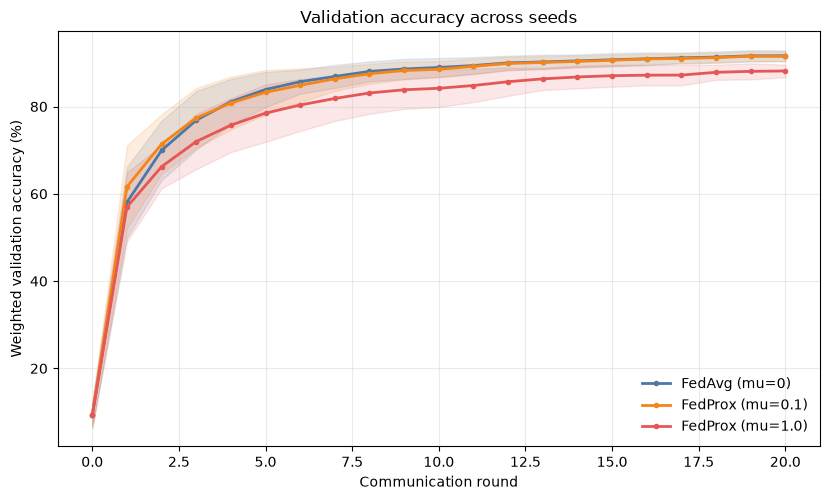

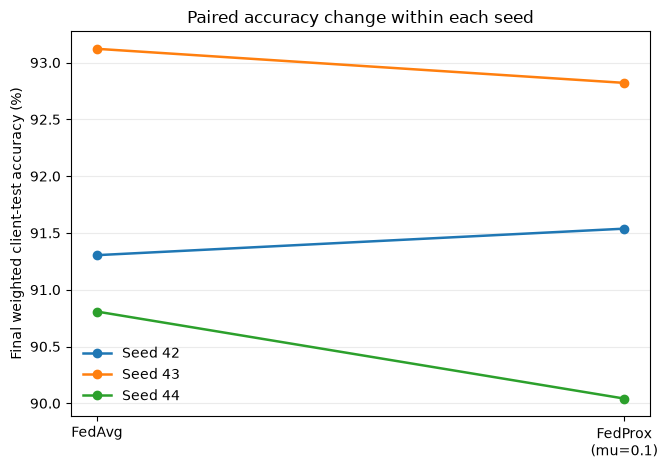

In [24]:
FIGURE_DIR = RESULTS_DIR / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

METHOD_COLORS = {0.0: "#4C78A8", 0.1: "#F58518", 1.0: "#E45756"}
METHOD_LABELS = {
    0.0: "FedAvg (mu=0)",
    0.1: "FedProx (mu=0.1)",
    1.0: "FedProx (mu=1.0)",
}


def plot_validation_trajectories(performance: pd.DataFrame):
    grouped = (
        performance.groupby(["mu", "round"])["weighted_accuracy"]
        .agg(["mean", "std"])
        .reset_index()
    )
    fig, ax = plt.subplots(figsize=(8.4, 5.1))
    for mu, group in grouped.groupby("mu", sort=True):
        x = group["round"].to_numpy()
        mean = group["mean"].to_numpy() * 100
        std = group["std"].fillna(0).to_numpy() * 100
        ax.plot(x, mean, marker="o", markersize=3, linewidth=2,
                color=METHOD_COLORS[float(mu)], label=METHOD_LABELS[float(mu)])
        ax.fill_between(x, mean - std, mean + std,
                        color=METHOD_COLORS[float(mu)], alpha=0.14)
    ax.set(title="Validation accuracy across seeds",
           xlabel="Communication round",
           ylabel="Weighted validation accuracy (%)")
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)
    fig.tight_layout()
    return fig


def plot_paired_accuracy(summary: pd.DataFrame):
    selected = summary[summary["mu"].isin([0.0, 0.1])]
    fig, ax = plt.subplots(figsize=(6.8, 4.8))
    for seed, group in selected.groupby("seed", sort=True):
        group = group.sort_values("mu")
        ax.plot([0, 1], group["final_weighted_test_accuracy"].to_numpy() * 100,
                marker="o", linewidth=1.8, label=f"Seed {seed}")
    ax.set_xticks([0, 1], ["FedAvg", "FedProx\n(mu=0.1)"])
    ax.set_ylabel("Final weighted client-test accuracy (%)")
    ax.set_title("Paired accuracy change within each seed")
    ax.grid(axis="y", alpha=0.25)
    ax.legend(frameon=False)
    fig.tight_layout()
    return fig


validation_fig = plot_validation_trajectories(performance_df)
validation_fig.savefig(FIGURE_DIR / "validation_accuracy_across_seeds.png", dpi=180, bbox_inches="tight")
plt.show()

paired_fig = plot_paired_accuracy(seed_mu_summary)
paired_fig.savefig(FIGURE_DIR / "paired_final_accuracy.png", dpi=180, bbox_inches="tight")
plt.show()

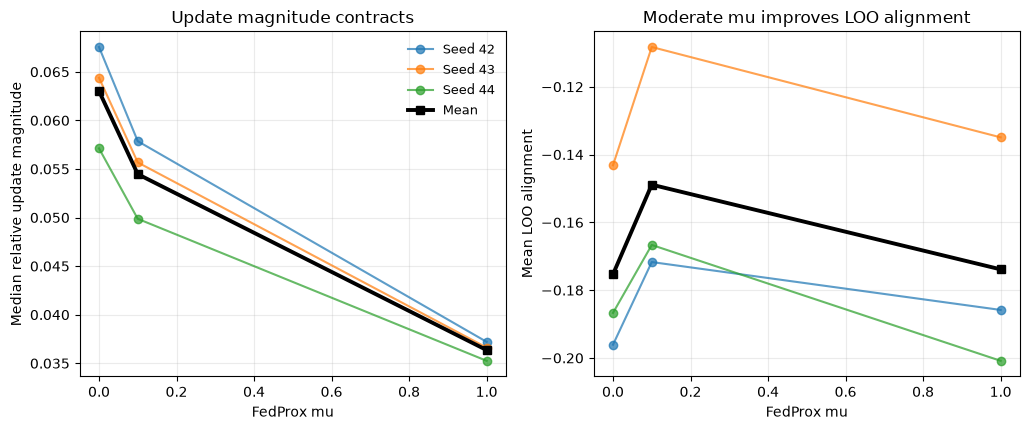

In [25]:
def plot_geometry_summary(summary: pd.DataFrame):
    fig, axes = plt.subplots(1, 2, figsize=(10.4, 4.4))
    for seed, group in summary.groupby("seed", sort=True):
        group = group.sort_values("mu")
        axes[0].plot(group["mu"], group["median_relative_update_magnitude"],
                     marker="o", alpha=0.72, label=f"Seed {seed}")
        axes[1].plot(group["mu"], group["mean_loo_alignment"],
                     marker="o", alpha=0.72, label=f"Seed {seed}")

    means = summary.groupby("mu", as_index=False).mean(numeric_only=True)
    axes[0].plot(means["mu"], means["median_relative_update_magnitude"],
                 color="black", marker="s", linewidth=2.8, label="Mean")
    axes[1].plot(means["mu"], means["mean_loo_alignment"],
                 color="black", marker="s", linewidth=2.8, label="Mean")

    axes[0].set(title="Update magnitude contracts", xlabel="FedProx mu",
                ylabel="Median relative update magnitude")
    axes[1].set(title="Moderate mu improves LOO alignment", xlabel="FedProx mu",
                ylabel="Mean LOO alignment")
    for ax in axes:
        ax.grid(alpha=0.25)
    axes[0].legend(frameon=False, fontsize=9)
    fig.tight_layout()
    return fig


geometry_fig = plot_geometry_summary(seed_mu_summary)
geometry_fig.savefig(FIGURE_DIR / "geometry_across_seeds.png", dpi=180, bbox_inches="tight")
plt.show()

## 17. Seed-44 fairness trade-off

Seed 44 is the clearest case where unweighted fairness metrics and weighted performance disagree. Clients are ordered by test-set size below so the weighting mechanism is visible rather than inferred from aggregate statistics.

In [26]:
seed_44 = client_test_df.query("seed == 44 and mu in [0.0, 0.1]")
seed_44_comparison = (
    seed_44.pivot(index=["client_id", "total"], columns="mu", values="accuracy")
    .reset_index()
    .sort_values("total", ascending=False)
    .reset_index(drop=True)
)
seed_44_comparison["difference"] = seed_44_comparison[0.1] - seed_44_comparison[0.0]
seed_44_comparison["client_weight"] = seed_44_comparison["total"] / seed_44_comparison["total"].sum()
seed_44_comparison["weighted_contribution"] = (
    seed_44_comparison["client_weight"] * seed_44_comparison["difference"]
)
display(seed_44_comparison)

mu,client_id,total,0.0,0.1,difference,client_weight,weighted_contribution
0,3,2708,0.956056,0.943870,-0.012186,0.450958,-0.005495
1,1,1921,0.881832,0.874545,-0.007288,0.319900,-0.002331
2,4,880,0.869318,0.862500,-0.006818,0.146545,-0.000999
3,2,440,0.825000,0.834091,0.009091,0.073272,0.000666
4,0,56,0.750000,0.803571,0.053571,0.009326,0.000500


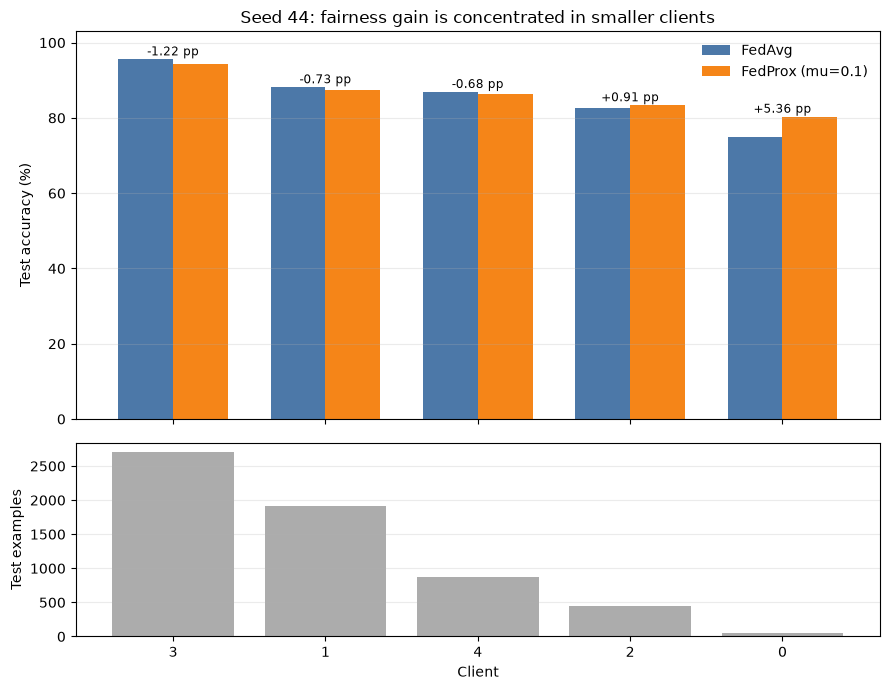

In [27]:
x = np.arange(len(seed_44_comparison))
width = 0.36
fig, (accuracy_ax, size_ax) = plt.subplots(
    2, 1, figsize=(9, 7), sharex=True,
    gridspec_kw={"height_ratios": [2, 1]},
)
accuracy_ax.bar(x - width / 2, seed_44_comparison[0.0] * 100, width,
                color=METHOD_COLORS[0.0], label="FedAvg")
accuracy_ax.bar(x + width / 2, seed_44_comparison[0.1] * 100, width,
                color=METHOD_COLORS[0.1], label="FedProx (mu=0.1)")
for idx, difference in enumerate(seed_44_comparison["difference"] * 100):
    height = max(seed_44_comparison.loc[idx, 0.0], seed_44_comparison.loc[idx, 0.1]) * 100
    accuracy_ax.text(idx, height + 1.0, f"{difference:+.2f} pp", ha="center", fontsize=8.5)
accuracy_ax.set_ylim(0, 103)
accuracy_ax.set_ylabel("Test accuracy (%)")
accuracy_ax.set_title("Seed 44: fairness gain is concentrated in smaller clients")
accuracy_ax.legend(frameon=False)
accuracy_ax.grid(axis="y", alpha=0.25)

size_ax.bar(x, seed_44_comparison["total"], color="#9E9E9E", alpha=0.85)
size_ax.set_ylabel("Test examples")
size_ax.set_xlabel("Client")
size_ax.set_xticks(x, seed_44_comparison["client_id"].astype(str))
size_ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "seed44_client_tradeoff.png", dpi=180, bbox_inches="tight")
plt.show()

## 18. Findings

### 18.1 Primary performance result

Moderate FedProx (`mu = 0.1`) did **not** reproduce a consistent weighted-accuracy advantage over FedAvg:

| Seed | Weighted test change | Worst-client change | Mean-client change | Validation AUC change |
|---:|---:|---:|---:|---:|
| 42 | +0.233 pp | +0.940 pp | +0.489 pp | +0.894 pp |
| 43 | -0.300 pp | -0.409 pp | -0.200 pp | -0.027 pp |
| 44 | -0.766 pp | +5.357 pp | +0.727 pp | -0.750 pp |
| **Mean paired change** | **-0.278 pp** | **+1.963 pp** | **+0.339 pp** | **+0.039 pp** |

It improved final weighted accuracy in only **1/3 seeds**. The average change was small and negative, while normalized validation AUC was essentially unchanged. The most defensible interpretation is that moderate FedProx has a small, partition-dependent effect on aggregate performance rather than a reliable benefit.

### 18.2 Fairness is suggestive but not stable

`mu = 0.1` improved worst-client accuracy in **2/3 seeds** and reduced within-seed client-accuracy dispersion in **2/3 seeds**. Mean dispersion decreased from 4.45 to 3.57 percentage points. However, the mean worst-client gain was dominated by seed 44.

In seed 44, the three largest clients lost accuracy while the two smallest improved. Client 0 rose from 75.0% to 80.36%, but it contained only 56 test examples—three additional correct predictions. Thus, FedProx redistributed performance toward smaller clients in this partition, but this is not sufficient evidence that it generally optimizes fairness.

### 18.3 Geometry changes are more reproducible than accuracy changes

Relative to FedAvg, `mu = 0.1`:

- reduced median relative update magnitude in **3/3 seeds**, from 0.0630 to 0.0545 on average—a **13.6% contraction**;
- made mean LOO alignment less negative in **3/3 seeds**, improving by 0.0264 on average;
- increased mean pairwise similarity in only **2/3 seeds**, with a negligible across-seed mean change of +0.0016.

Therefore, moderate FedProx reliably constrains local movement and improves one weighted notion of agreement, but those changes do not guarantee a better predictive direction. Clients may agree more because updates are suppressed, not because the shared update is more useful.

### 18.4 Strong proximal regularization underfits

`mu = 1.0` contracted mean median relative update magnitude to 0.0364, but reduced mean weighted test accuracy by 3.86 percentage points, mean worst-client accuracy by 9.52 points, and normalized validation AUC by 4.10 points relative to FedAvg. This is consistent with over-constraining local adaptation.

### 18.5 Answer to the research question

> Moderate FedProx consistently changes update scale and LOO alignment, but it does not consistently improve performance. The seed-42 accuracy gain was partition-specific. Fairness improvements are possible, yet they are heterogeneous and can reflect a trade-off between small and large clients.

Runtime was effectively unchanged across methods (approximately 18 minutes per condition); the small differences are ordinary execution noise rather than evidence of a speed advantage.

## 19. Limitations and next experiment

- Only three seeded federated worlds were evaluated; the results support directional replication, not significance claims.
- Each seed jointly changes partition, split, initialization, and batch schedule. This matches the chosen experimental unit but does not isolate which source of randomness drives variation.
- The study uses five fully participating clients, one Dirichlet concentration (`alpha = 0.1`), one MLP, and one local-training regime.
- Worst-client metrics can be volatile when a client has a very small test set, as in seed 44.
- The archived `client_performance_history.csv` is invalid because of the corrected adapter bug documented in Section 14. Final client-test metrics and all reported aggregate/geometry conclusions are unaffected.

### Next step: Notebook 07

Compare **FedAvg**, the preselected moderate **FedProx (`mu = 0.1`)**, and **SCAFFOLD** using the exact saved partitions, splits, and initial model states from seeds 42–44. The next question is whether explicitly correcting client drift improves performance or fairness more reliably than merely shrinking updates.